# CHIRPS

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [11]:
import ocha_stratus as stratus
import pandas as pd

from src.constants import *
from src.utils.aggregation import groupby_weighted_mean

In [4]:
blob_name = f"{PROJECT_PREFIX}/raw/chirps/mrt-rainfall-subnat-full.csv"
df_raw = stratus.load_csv_from_blob(blob_name)

In [13]:
df_raw["date"] = pd.to_datetime(df_raw["date"])

In [23]:
season_months = [7, 8, 9]

In [26]:
df_season = df_raw[df_raw["date"].dt.month.isin(season_months)].copy()

In [27]:
df_season_aoi = df_season[df_season["PCODE"].isin(ADM1_AOI_PCODES)].copy()

In [69]:
df_dek_all = groupby_weighted_mean(
    df_season,
    group_cols="date",
    value_col="rfh",
    weight_col="n_pixels",
    result_name="rfh",
)

In [70]:
df_dek_aoi = groupby_weighted_mean(
    df_season_aoi,
    group_cols="date",
    value_col="rfh",
    weight_col="n_pixels",
    result_name="rfh",
)

In [71]:
df_dek = df_dek_all.merge(df_dek_aoi, on="date", suffixes=("_all", "_aoi"))

In [72]:
df_dek = df_dek.sort_values("date")
df_dek["year"] = df_dek["date"].dt.year

In [73]:
for x in ["all", "aoi"]:
    df_dek[f"rfh_{x}_cumul"] = df_dek.groupby("year")[f"rfh_{x}"].cumsum()

In [74]:
df_dek["dekad"] = df_dek["date"].dt.day.floordiv(10) + 1

In [85]:
df_dek[df_dek["year"] == 2002]

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall
189,2002-07-01,3.110586,19.053764,2002,3.110586,19.053764,1,19
190,2002-07-11,2.577410,7.338393,2002,5.687996,26.392157,2,20
191,2002-07-21,3.900542,5.296648,2002,9.588538,31.688805,3,21
192,2002-08-01,7.747614,27.371283,2002,17.336152,59.060088,1,22
193,2002-08-11,10.930060,43.340289,2002,28.266212,102.400378,2,23
194,2002-08-21,8.513868,30.759646,2002,36.780081,133.160023,3,24
195,2002-09-01,6.867158,25.781784,2002,43.647239,158.941807,1,25
196,2002-09-11,8.044262,25.259330,2002,51.691501,184.201138,2,26
197,2002-09-21,6.587397,13.595193,2002,58.278898,197.796330,3,27


In [76]:
df_dek["dekad_overall"] = (df_dek["date"].dt.month - 1) * 3 + df_dek["dekad"]

<Axes: xlabel='dekad_overall'>

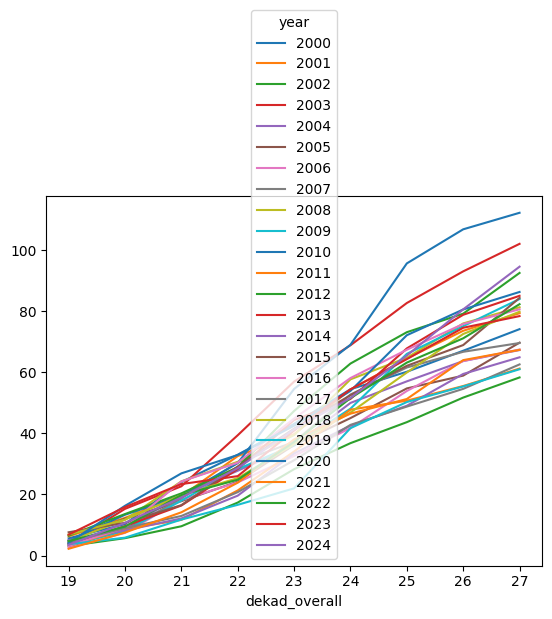

In [87]:
sel_years = range(2000, 2025)
df_dek[df_dek["year"].isin(sel_years)].pivot(
    index="dekad_overall", columns="year", values="rfh_all_cumul"
).plot()

In [90]:
blob_name = (
    f"{PROJECT_PREFIX}/processed/chirps/chirps_dek_season_cumul.parquet"
)
stratus.upload_parquet_to_blob(df_dek, blob_name)